# Trader Behavior Modeling

## Objective
Build predictive models to estimate trader profitability using:
- market sentiment
- behavioral trading features

## Modeling Approaches
1. Logistic Regression (baseline)
2. Random Forest (nonlinear model)
3. K-Means Clustering for trader archetypes

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# Clustering (Trader Archetypes)
from sklearn.cluster import KMeans
# Utility Settings
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

%matplotlib inline

In [2]:
historical = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Historical shape:", historical.shape)
print("Sentiment shape:", sentiment.shape)

historical.head()

Historical shape: (211224, 16)
Sentiment shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
sentiment.head()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [4]:
sentiment = sentiment.rename(columns={
    "value": "sentiment_score",
    "classification": "sentiment"
})

In [5]:
historical["date"] = pd.to_datetime(historical["Timestamp"]).dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [6]:
df = historical.merge(
    sentiment[["date", "sentiment_score", "sentiment"]],
    on="date",
    how="left"
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,sentiment_score,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,1970-01-01,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,1970-01-01,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,1970-01-01,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,1970-01-01,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,1970-01-01,NaN,NaN


In [7]:
df.isnull().sum()

Account                  0
Coin                     0
Execution Price          0
Size Tokens              0
Size USD                 0
Side                     0
Timestamp IST            0
Start Position           0
Direction                0
Closed PnL               0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp                0
date                     0
sentiment_score     211224
sentiment           211224
dtype: int64

In [8]:
historical["date"] = pd.to_datetime(
    historical["Timestamp IST"],
    dayfirst=True
).dt.date

In [9]:
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [10]:
print(historical["date"].head())
print(sentiment["date"].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [11]:
df = historical.merge(
    sentiment[["date","sentiment_score","sentiment"]],
    on="date",
    how="left"
)

In [12]:
df[["sentiment_score","sentiment"]].isnull().sum()

sentiment_score    6
sentiment          6
dtype: int64

In [13]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,sentiment_score,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [14]:
df = df.dropna(subset=["sentiment_score", "sentiment"])

In [15]:
df.isnull().sum()
print(df.shape)

(211218, 19)


In [16]:
df["sentiment"].value_counts()

sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [17]:
df["Closed PnL"].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [18]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'sentiment_score', 'sentiment'],
      dtype='object')

### Feature Engineering 

In [19]:
# Create Trade Outcome Indicator (Win / Loss)
df["win"] = (df["Closed PnL"] > 0).astype(int)

In [20]:
# Trader Trade Frequency
df["trade_frequency"] = df.groupby("Account")["Trade ID"].transform("count")

In [21]:
# Average Position Size
df["avg_position_size"] = df.groupby("Account")["Size USD"].transform("mean")

In [22]:
# Trader Win Rate
df["win_rate"] = df.groupby("Account")["win"].transform("mean")

In [23]:
# Previous Trade PnL (Behavior Momentum Feature)
df = df.sort_values(["Account", "Timestamp IST"])

df["prev_trade_pnl"] = df.groupby("Account")["Closed PnL"].shift(1)

df["prev_trade_pnl"] = df["prev_trade_pnl"].fillna(0)

In [24]:
# Leverage Proxy
df["leverage_proxy"] = df["Size USD"] / df["Execution Price"]

In [25]:
# Profitability Buckets (Model Target)
def profit_bucket(pnl):
    
    if pnl < 0:
        return 0   # Loss
    
    elif pnl < 100:
        return 1   # Small Profit
    
    else:
        return 2   # Large Profit


df["profit_bucket"] = df["Closed PnL"].apply(profit_bucket)

In [26]:
df[[
    "trade_frequency",
    "avg_position_size",
    "win_rate",
    "prev_trade_pnl",
    "leverage_proxy"
]].head()

,trade_frequency,avg_position_size,win_rate,prev_trade_pnl,leverage_proxy
17325,3818,16159.576734,0.359612,0.000000,0.222000
17326,3818,16159.576734,0.359612,70.953420,0.351998
17327,3818,16159.576734,0.359612,112.502720,0.229998
17328,3818,16159.576734,0.359612,73.510300,0.151402
17329,3818,16159.576734,0.359612,48.388954,0.148501


## Feature Engineering

Behavioral features were constructed to capture trader activity:

- **trade_frequency** – number of trades per trader
- **avg_position_size** – average capital deployed
- **win_rate** – ratio of profitable trades
- **prev_trade_pnl** – previous trade performance
- **leverage_proxy** – exposure relative to asset price

In [27]:
# Final Modeling Features
features = [
    "sentiment_score",
    "trade_frequency",
    "avg_position_size",
    "win_rate",
    "prev_trade_pnl",
    "leverage_proxy"
]

X = df[features]

y = df["profit_bucket"]

In [28]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (168974, 6)
Test shape: (42244, 6)


In [29]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Baseline Model — Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [31]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy:
0.852476091279235

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.08      0.14      3564
           1       0.85      1.00      0.92     35717
           2       0.64      0.04      0.07      2963

    accuracy                           0.85     42244
   macro avg       0.80      0.37      0.38     42244
weighted avg       0.84      0.85      0.79     42244



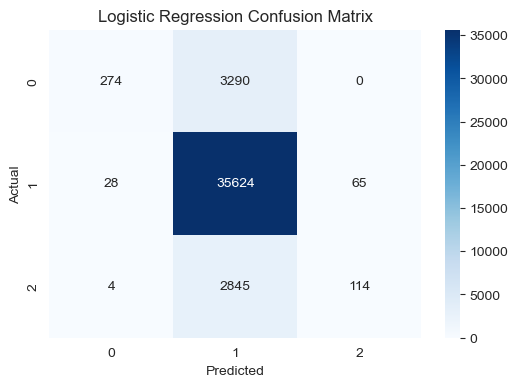

In [32]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [34]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.9515434144493893

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      3564
           1       0.96      0.98      0.97     35717
           2       0.82      0.70      0.76      2963

    accuracy                           0.95     42244
   macro avg       0.90      0.85      0.87     42244
weighted avg       0.95      0.95      0.95     42244



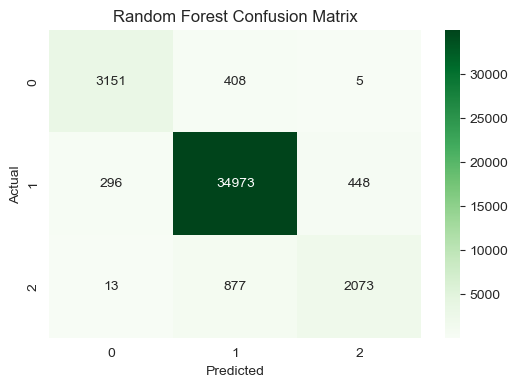

In [35]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

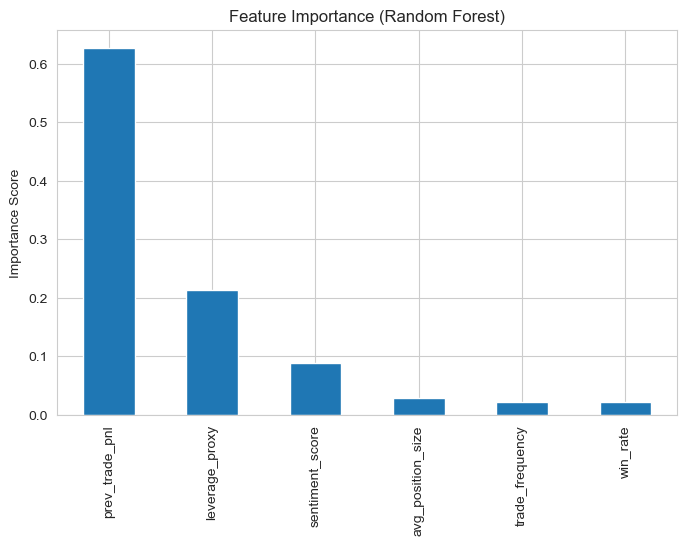

In [36]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

## Model Performance Insights

Random Forest significantly outperformed Logistic Regression.

Key findings:

- Trader momentum (previous trade PnL) strongly predicts next trade outcome
- Risk exposure (leverage proxy) influences profitability
- Market sentiment contributes to prediction but is not the dominant factor

#### Clustering traders into behavioral archetypes


In [37]:
cluster_features = [
    "trade_frequency",
    "avg_position_size",
    "win_rate",
    "leverage_proxy"
]

cluster_data = df[cluster_features]

In [38]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

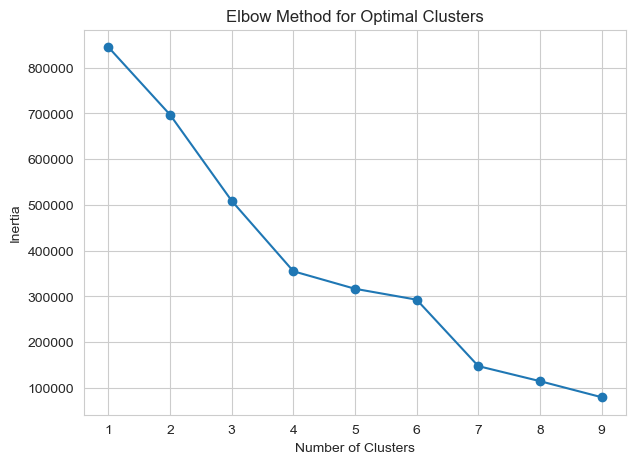

In [39]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["trader_cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_summary = df.groupby("trader_cluster")[cluster_features].mean()
cluster_summary

,trade_frequency,avg_position_size,win_rate,leverage_proxy
trader_cluster,,,,
0,9872.539437,2609.073128,0.809282,67727.410513
1,11236.880433,3897.397437,0.378973,2067.146465
2,10139.741127,31026.917972,0.411796,101.635299
3,40184.000000,1844.211886,0.428230,96.488306


In [41]:
cluster_profit = df.groupby("trader_cluster")["Closed PnL"].mean()

cluster_profit

trader_cluster
0    39.220842
1    56.697960
2    50.539479
3    20.806305
Name: Closed PnL, dtype: float64

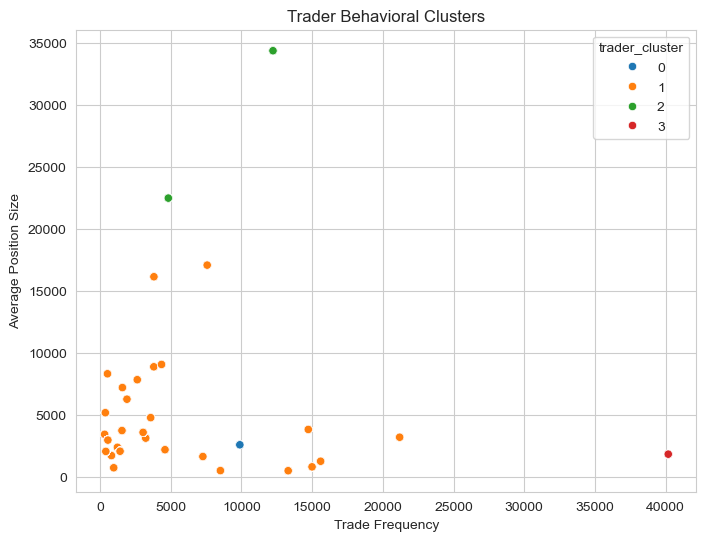

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["trade_frequency"],
    y=df["avg_position_size"],
    hue=df["trader_cluster"],
    palette="tab10"
)

plt.title("Trader Behavioral Clusters")
plt.xlabel("Trade Frequency")
plt.ylabel("Average Position Size")
plt.show()

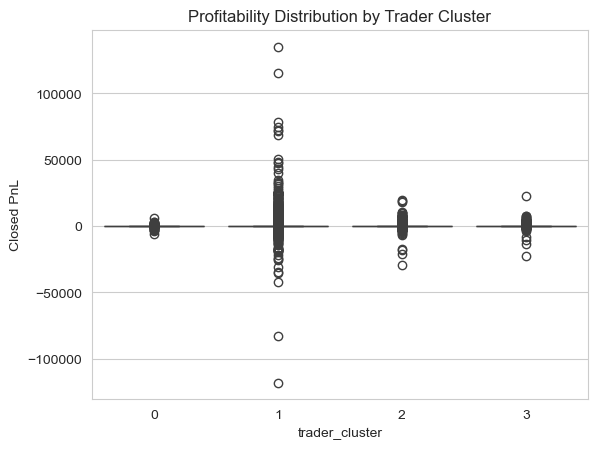

In [43]:
sns.boxplot(x="trader_cluster", y="Closed PnL", data=df)

plt.title("Profitability Distribution by Trader Cluster")
plt.show()

## Trader Behavioral Archetypes

K-Means clustering identified four trader groups based on behavioral patterns.

Examples of potential archetypes:

- High-frequency traders
- Large-position risk takers
- Conservative traders
- Opportunistic traders

These clusters show different profitability profiles, suggesting trader style influences performance.

In [44]:
def risk_label(pnl):
    if pnl < 0:
        return "High"
    elif pnl < 50:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df["Closed PnL"].apply(risk_label)

In [45]:
features = [
    "sentiment_score",
    "Closed PnL"
    # add more if you created
]

X = df[features]
y = df["risk_level"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [47]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [48]:
df["cluster"] = kmeans.labels_
cluster_map = {
    0: "Safe Trader",
    1: "Aggressive Trader",
    2: "Overtrader"
}

df["trader_type"] = df["cluster"].map(cluster_map)

In [51]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [55]:
import pandas as pd

sample = pd.DataFrame([[0.5, -20]], columns=X_train.columns)

model.predict(sample)

array(['High'], dtype=object)

In [56]:
import pickle

# Save
pickle.dump(model, open("model.pkl", "wb"))

# Load
loaded_model = pickle.load(open("model.pkl", "rb"))

# Test again
loaded_model.predict(sample)

array(['High'], dtype=object)